# qqbar-trained vs hss-trained HGPflow, on the HSS 30k test set

Compares two models evaluated on the **same** HSS test sample:
- **`hgpflow_qqbar`** — model trained on qqbar (out-of-domain here)
- **`hgpflow_hss`** — model trained on hss (in-domain)
- **`ppflow`** — parametric particle-flow baseline (from the truth file)

Same jet plots as `cocoa_hss_performance.ipynb`, but the three curves are the two
models' outputs + the PPflow baseline (instead of hgpflow/proxy/ppflow of one model).
Two `PerformanceCOCOA` objects share one truth file, so `ppflow` and the truth jets are
identical across both.

In [2]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
os.environ['PYTHONPATH'] = ':'.join(sys.path)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import hgpflow_v2.performance  # don't know why this is needed, but it is
from hgpflow_v2.performance.performance import PerformanceCOCOA
from hgpflow_v2.performance.plot_helper_event import compute_jet_residual_dict, plot_jet_residuals
from hgpflow_v2.performance.llp_helper import tag_truth_jets_llp, select_matched_by_llp

## Custom 3-curve stylesheet
`plot_jet_residuals` looks up style by curve name and `update_stylesheet` **replaces** each
dict wholesale, so we define every field for exactly our three keys.

In [4]:
STYLE = {
    'COLORS':      {'ppflow': 'gray', 'hgpflow_qqbar': 'teal',      'hgpflow_hss': 'firebrick'},
    'LABELS':      {'ppflow': 'PPflow', 'hgpflow_qqbar': 'HGPflow (qqbar-trained)', 'hgpflow_hss': 'HGPflow (hss-trained)'},
    'HISTTYPES':   {'ppflow': 'bar', 'hgpflow_qqbar': 'step',       'hgpflow_hss': 'step'},
    'ALPHAS':      {'ppflow': 0.5, 'hgpflow_qqbar': 1.0,            'hgpflow_hss': 1.0},
    'LINE_STYLES': {'ppflow': '-', 'hgpflow_qqbar': '--',          'hgpflow_hss': '-'},
    'LABEL_LEN':   {'ppflow': 10, 'hgpflow_qqbar': 22,             'hgpflow_hss': 20},
}

## Build both perf objects on the same truth

In [5]:
QQBAR_RUN = '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25'
HSS_RUN   = '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largehsstraining4node25epoch'
TRUTH     = '/pscratch/sd/a/agolub/hss_events/HSS_events_with_ppflow/cocoa_hss_pflow_30k.root'

perf_qqbar = PerformanceCOCOA(
    truth_path=TRUTH,
    pred_path=f'{QQBAR_RUN}/inference/hss_ppflow/pred_*_merged.root',
    ind_threshold=0.4, event_number_offset=0, llp_lxy_mm=10)

perf_hss = PerformanceCOCOA(
    truth_path=TRUTH,
    pred_path=f'{HSS_RUN}/inference/hss_test/pred_*_merged.root',
    ind_threshold=0.4, event_number_offset=0, llp_lxy_mm=10)

# alignment guard for each -- expect ~0.9+ (low ~0.2 => wrong file/offset)
for name, perf in [('qqbar', perf_qqbar), ('hss', perf_hss)]:
    ts = np.array([x.sum() for x in perf.truth_dict['particle_pt']])
    hs = np.array([x.sum() for x in perf.hgpflow_dict['hgpflow_pt']])
    print(f'{name:6s} alignment corr:', np.corrcoef(ts, hs)[0, 1].round(3))

Computing HGPFlow mass...: 100%|██████████| 29976/29976 [00:00<00:00, 47677.76it/s]


E, pT will be scaled by 0.001


Applying fiducial cuts...: 100%|██████████| 30000/30000 [00:00<00:00, 58252.68it/s]
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:196: RuntimeWarning: invalid value encountered in sqrt
  truth_dict['particle_mass'].append(np.sqrt(e**2 - p**2))
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:204: RuntimeWarning: invalid value encountered in sqrt
  truth_dict['pflow_mass'].append(np.sqrt(e**2 - p**2))


common event count: 29976


Computing HGPFlow mass...: 100%|██████████| 29976/29976 [00:00<00:00, 44266.66it/s]


E, pT will be scaled by 0.001


Applying fiducial cuts...: 100%|██████████| 30000/30000 [00:00<00:00, 59482.14it/s]


common event count: 29976


Filtering and reordering HGPFlow...: 100%|██████████| 12/12 [00:00<00:00, 2094.88it/s]


qqbar  alignment corr: 0.922
hss    alignment corr: 0.942


In [6]:
for perf in (perf_qqbar, perf_hss):
    perf.compute_jets(radius=0.4, algo='antikt', store_constituent_idxs=True)  # True -> enables LLP tagging below
    perf.match_jets()
    tag_truth_jets_llp(perf)   # tag truth jets by LLP fraction (same truth -> identical tags)

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
truth


Computing jets...:   0%|          | 1/29976 [00:00<59:34,  8.39it/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Computing jets...: 100%|██████████| 29976/29976 [01:40<00:00, 298.21it/s]


ppflow


...

proxy


Computing jets...: 100%|██████████| 29976/29976 [02:24<00:00, 207.15it/s]


hgpflow


Matching jets...: 100%|██████████| 29976/29976 [00:00<00:00, 41269.93it/s]


tagged 99291 truth jets with .llp_frac (Lxy > 10 mm = LLP-origin)


## All jets: ppflow vs hgpflow_qqbar vs hgpflow_hss
`ppflow` and the truth jets are identical between the two perf objects, so we take
`ppflow` from either one.

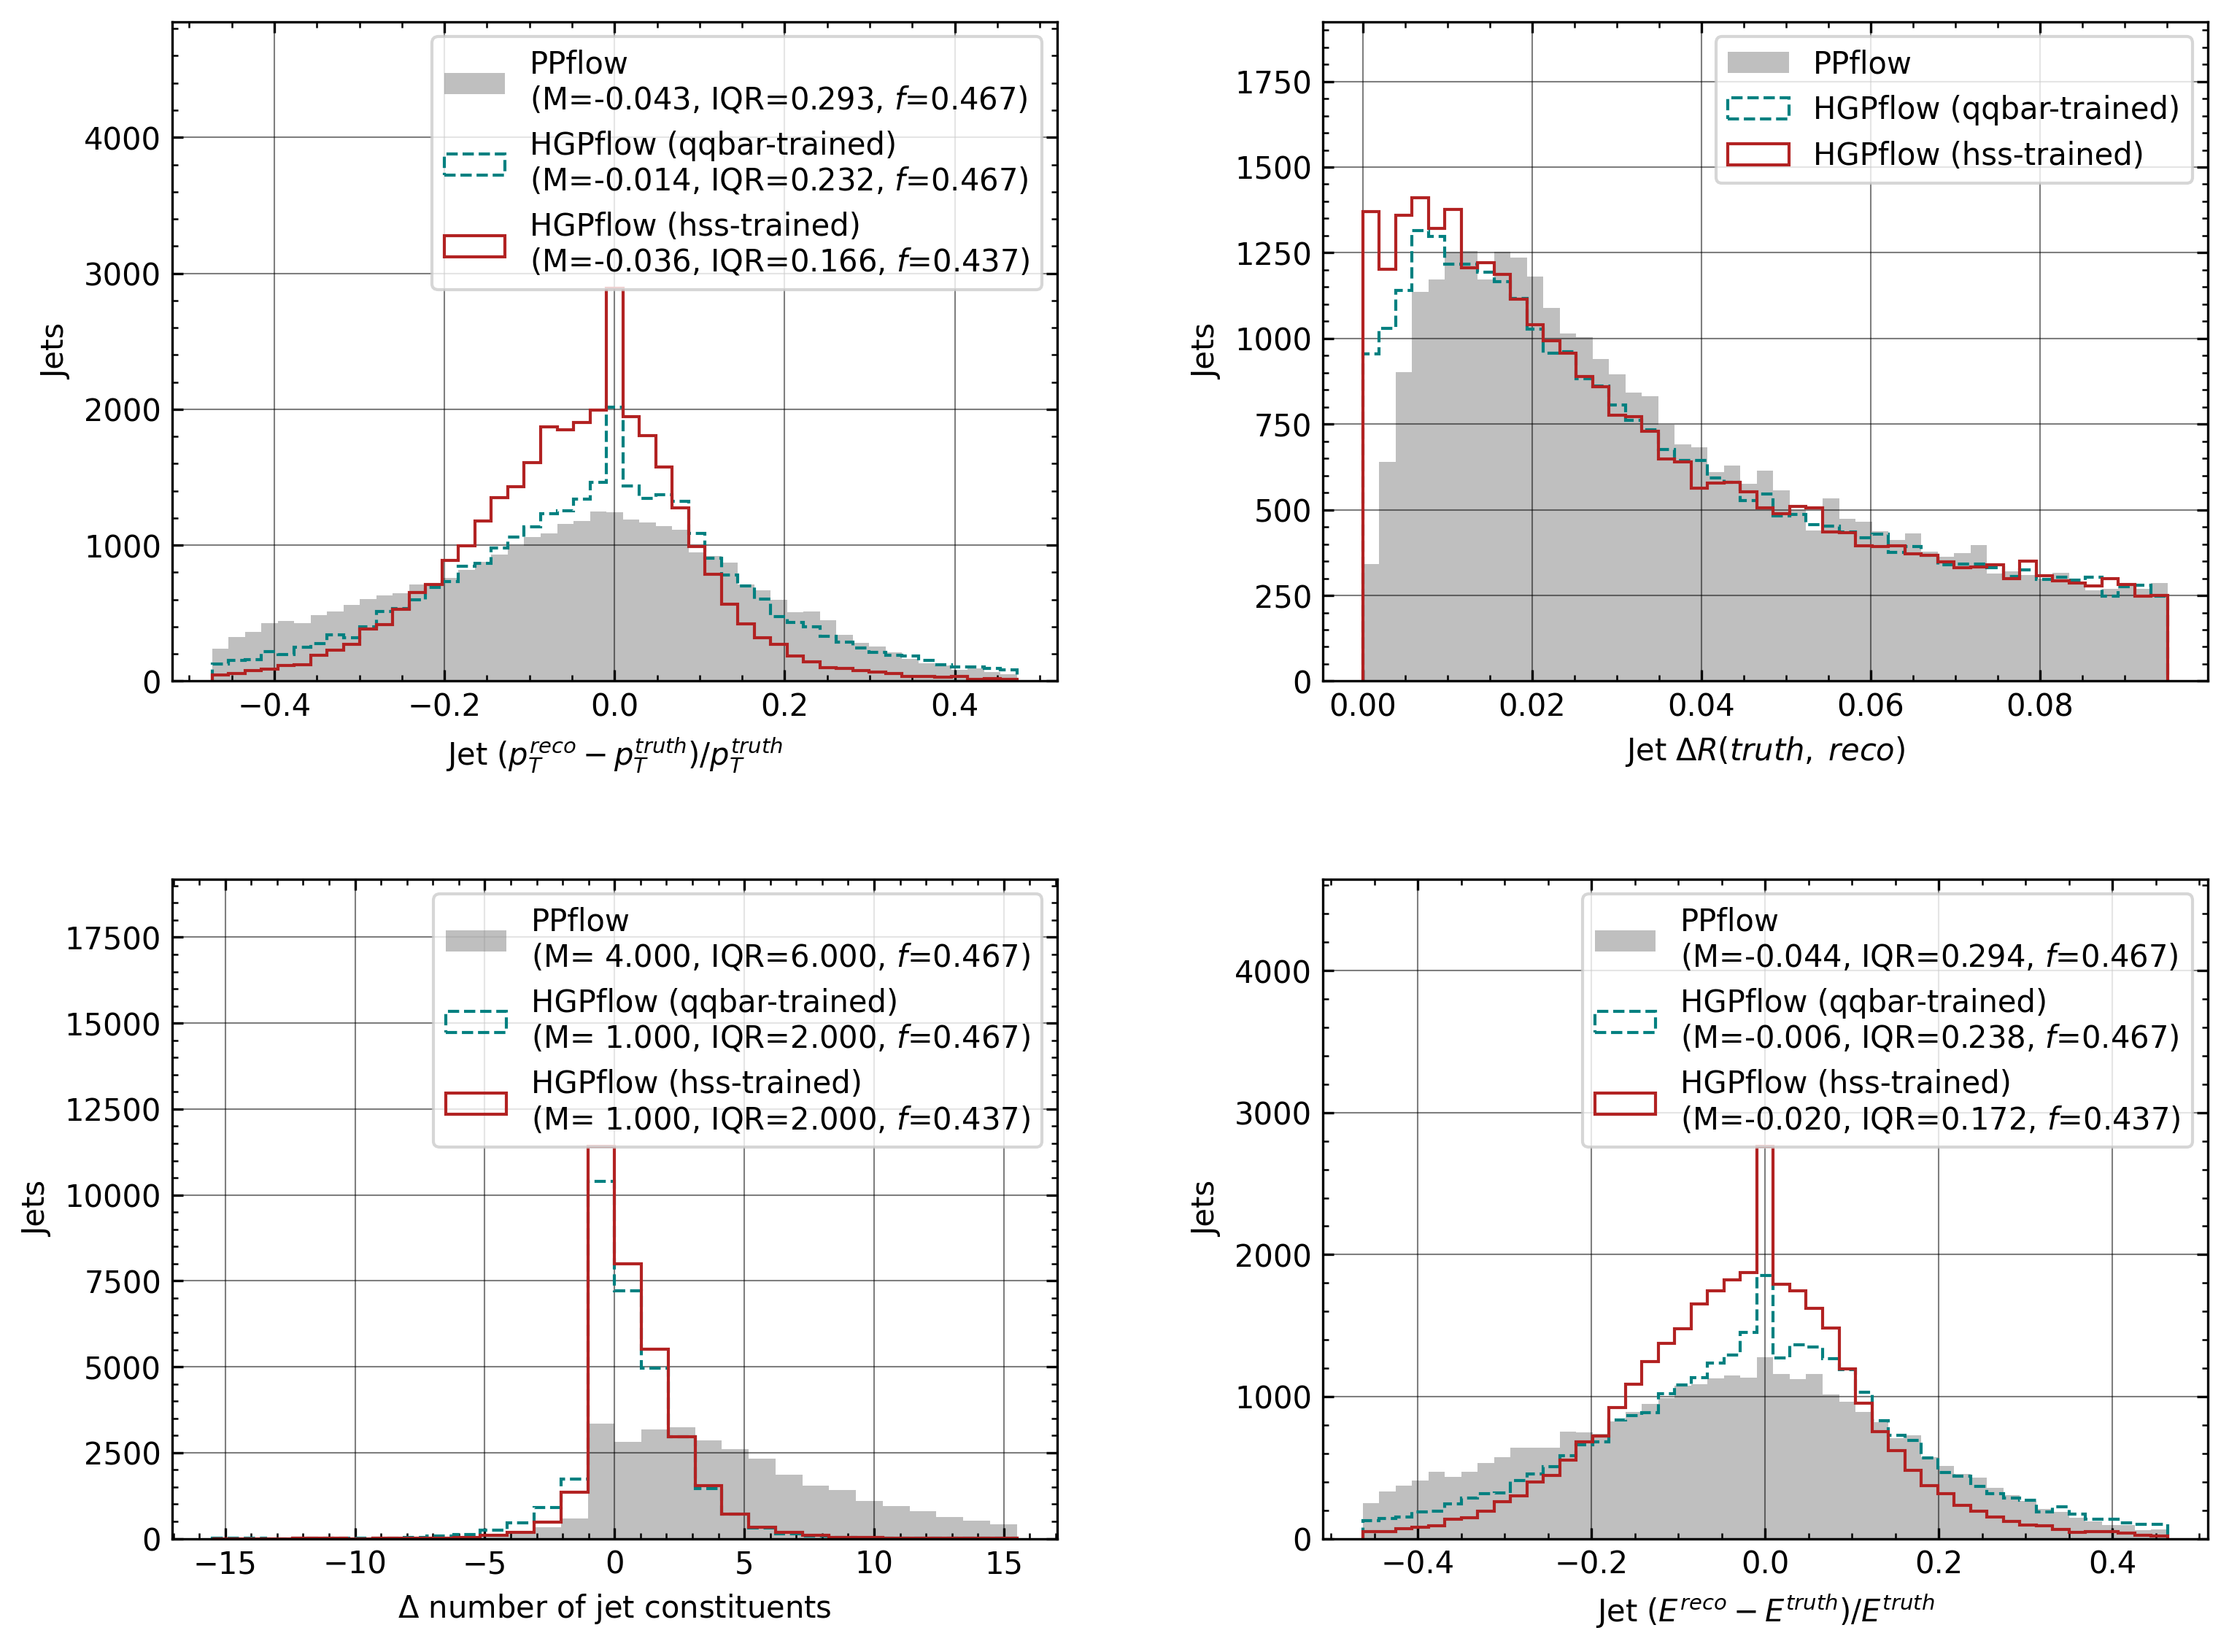

In [7]:
residual_dict = compute_jet_residual_dict({
    'ppflow':        perf_qqbar.truth_dict['matched_ppflow_jets'],
    'hgpflow_qqbar': perf_qqbar.hgpflow_dict['matched_hgpflow_jets'],
    'hgpflow_hss':   perf_hss.hgpflow_dict['matched_hgpflow_jets'],
})
fig = plot_jet_residuals(residual_dict, pt_relative=True, stylesheet=STYLE)
fig.savefig('hss_test_qqbar_vs_hss_jet_residuals.png', dpi=150, bbox_inches='tight')

## LLP jets only: ppflow vs hgpflow_qqbar vs hgpflow_hss
`FRAC` is the LLP-fraction cut on the (shared) truth jets; each curve is that model's
reco of the same displaced truth jets.

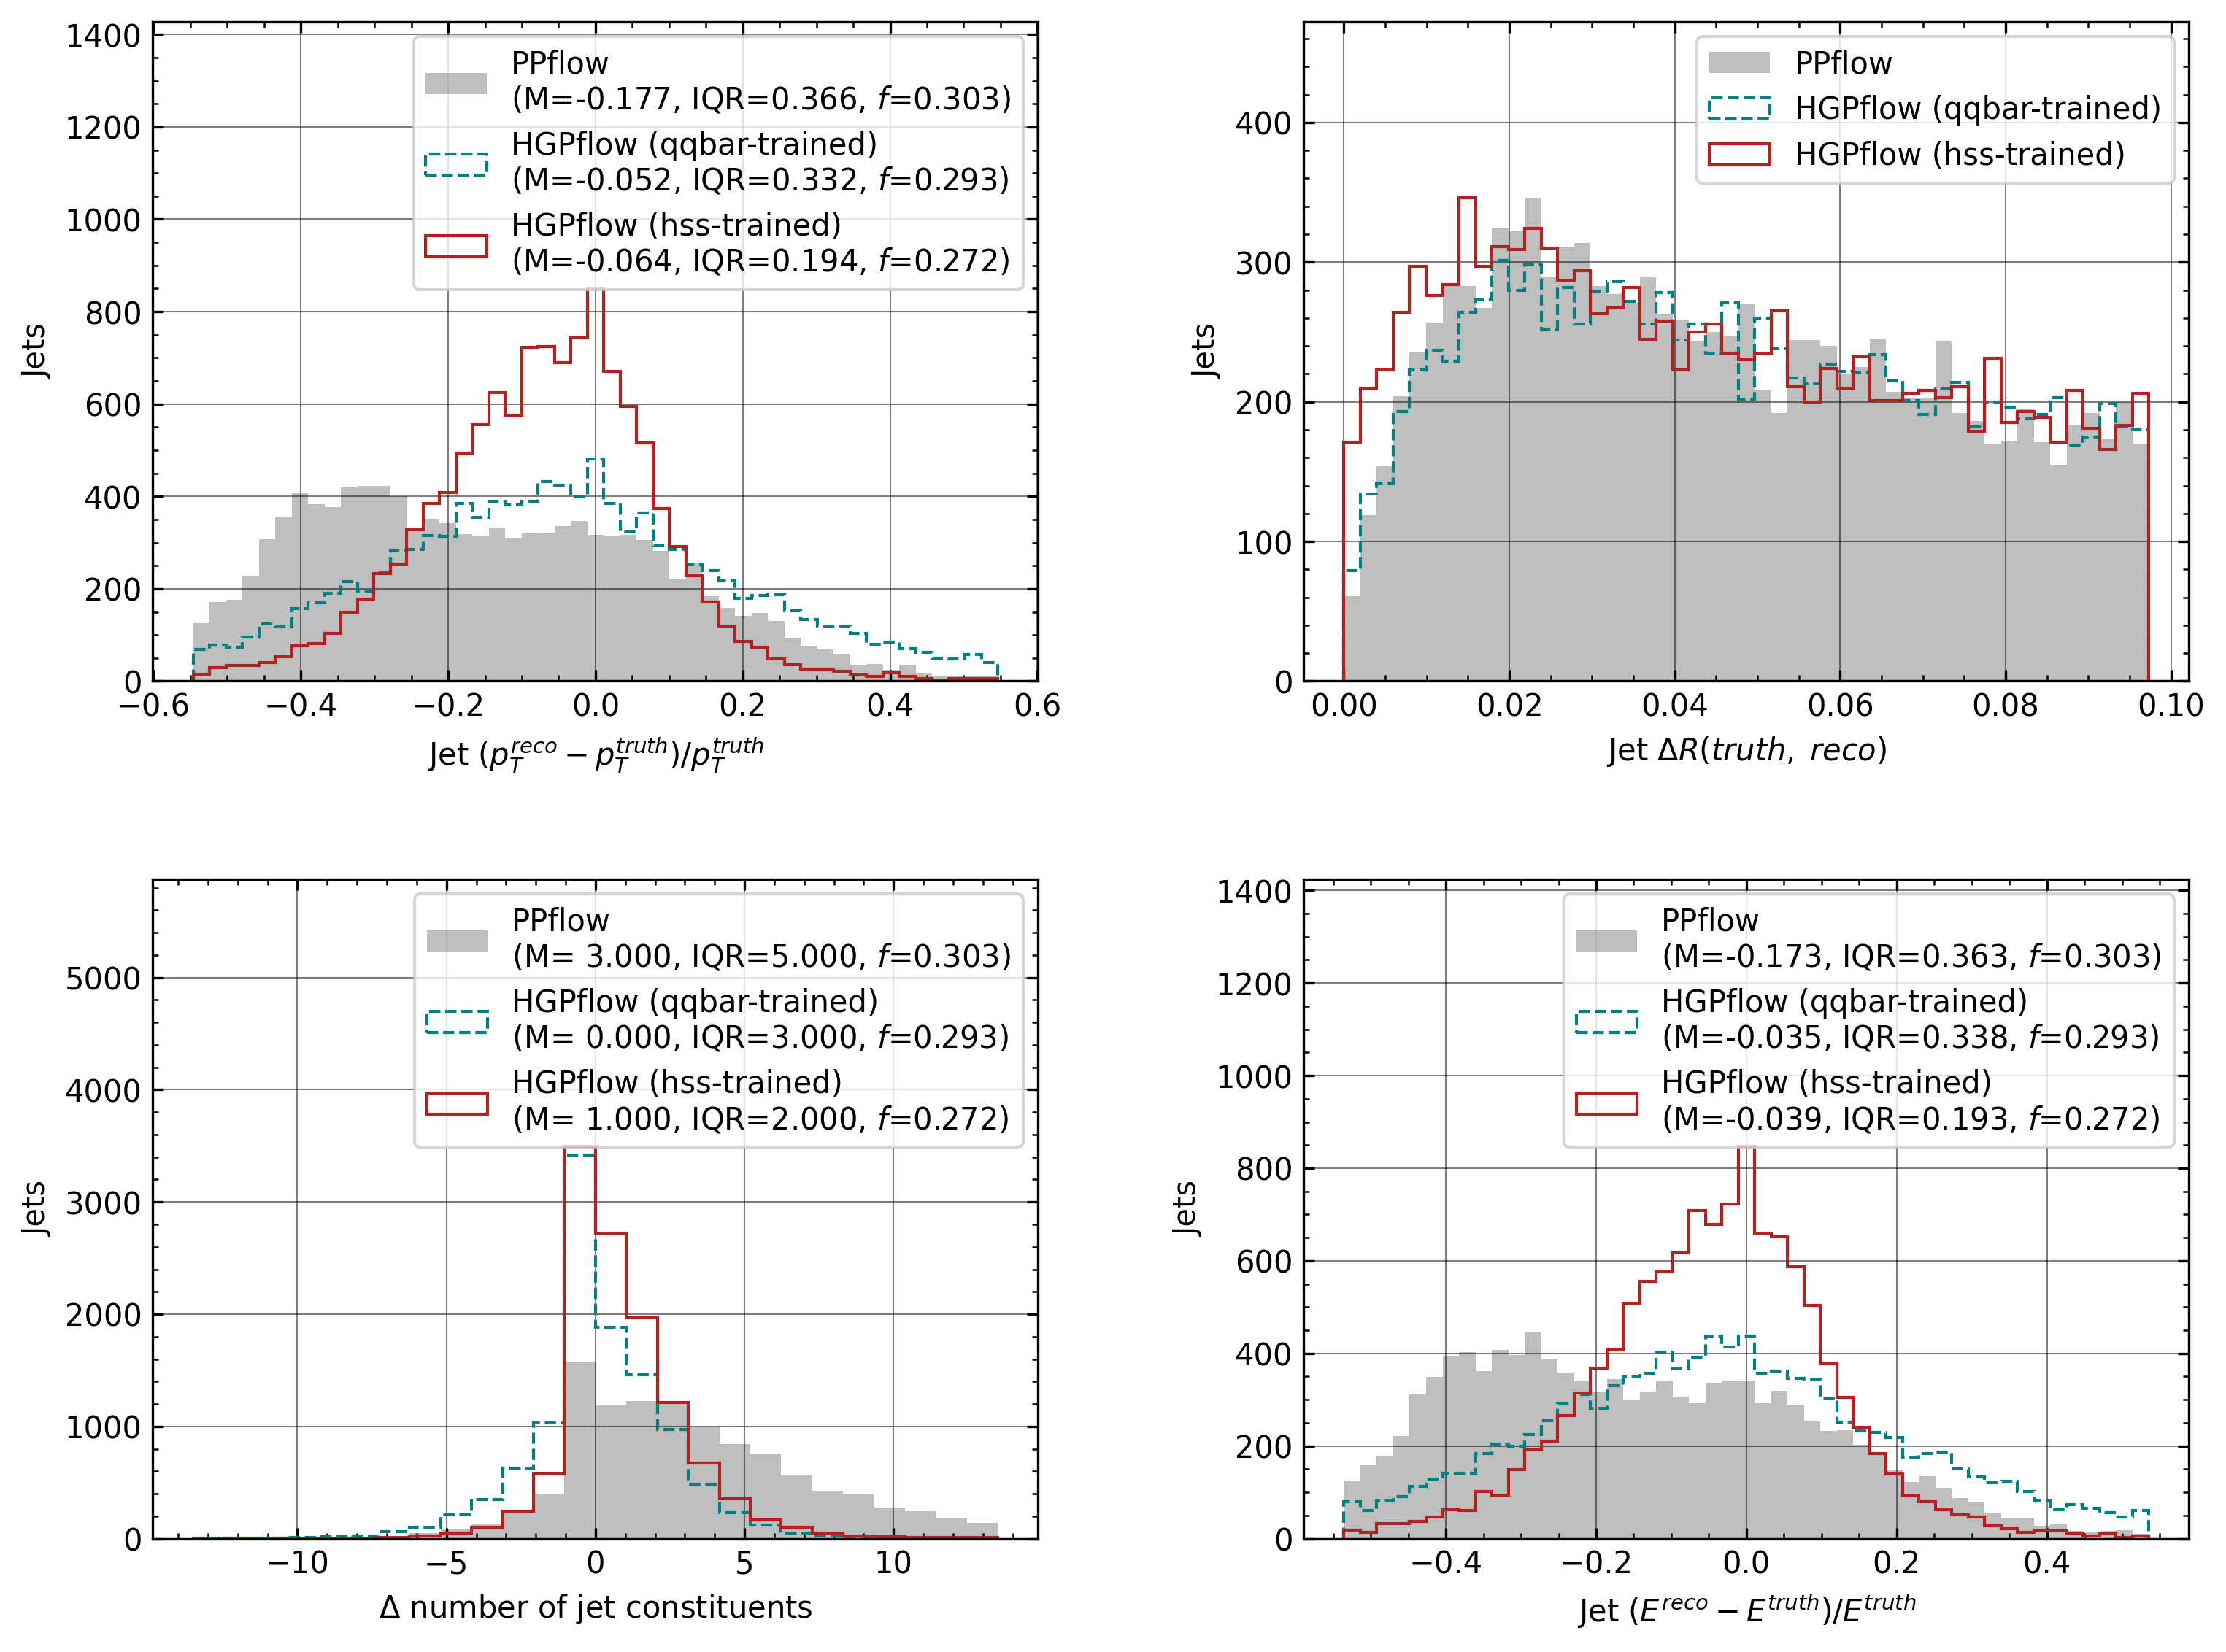

In [8]:
FRAC = 0.9
residual_dict_llp = compute_jet_residual_dict({
    'ppflow':        select_matched_by_llp(perf_qqbar.truth_dict['matched_ppflow_jets'],    FRAC, keep='llp'),
    'hgpflow_qqbar': select_matched_by_llp(perf_qqbar.hgpflow_dict['matched_hgpflow_jets'], FRAC, keep='llp'),
    'hgpflow_hss':   select_matched_by_llp(perf_hss.hgpflow_dict['matched_hgpflow_jets'],   FRAC, keep='llp'),
})
fig = plot_jet_residuals(residual_dict_llp, pt_relative=True, stylesheet=STYLE)
fig.savefig(f'hss_test_qqbar_vs_hss_jet_residuals_llp{int(FRAC*100)}.png', dpi=150, bbox_inches='tight')

## Increasing the dR cut to 0.2 - replotting

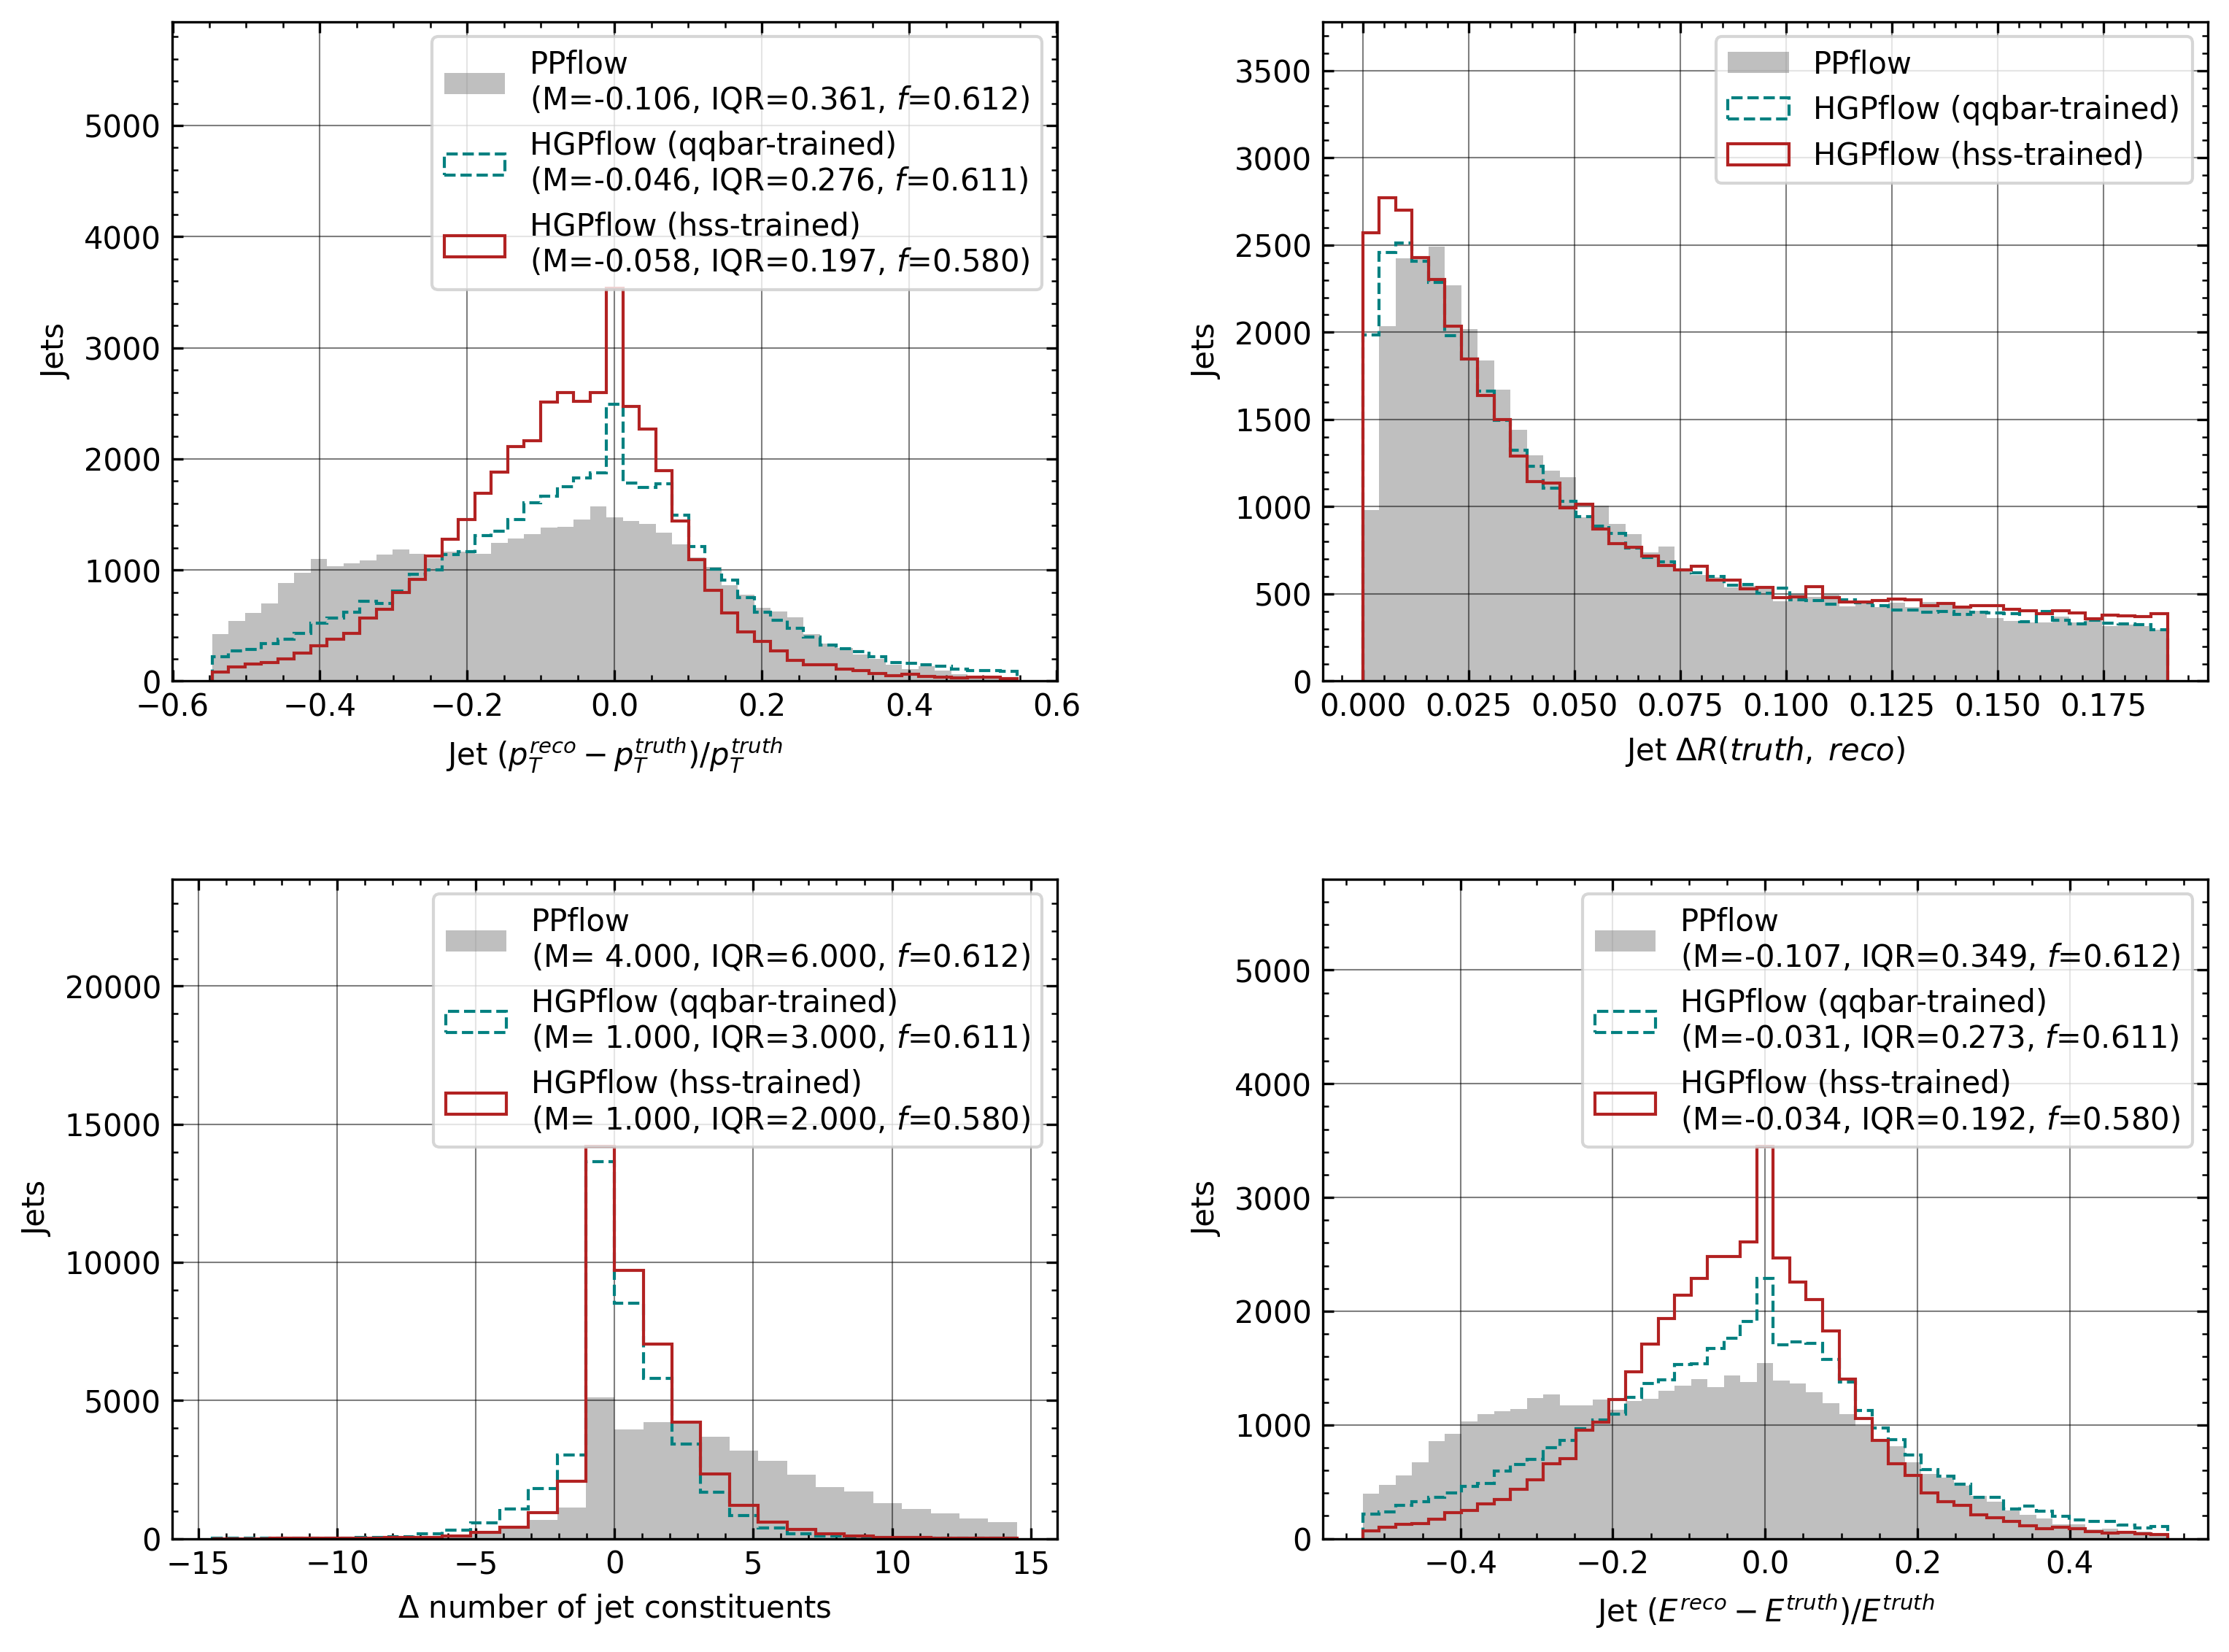

In [9]:
# For all jets
residual_dict = compute_jet_residual_dict({
    'ppflow':        perf_qqbar.truth_dict['matched_ppflow_jets'],
    'hgpflow_qqbar': perf_qqbar.hgpflow_dict['matched_hgpflow_jets'],
    'hgpflow_hss':   perf_hss.hgpflow_dict['matched_hgpflow_jets'],
}, dr_cut=0.2)
fig = plot_jet_residuals(residual_dict, pt_relative=True, stylesheet=STYLE)
fig.savefig('hss_test_qqbar_vs_hss_jet_residuals.png', dpi=150, bbox_inches='tight')

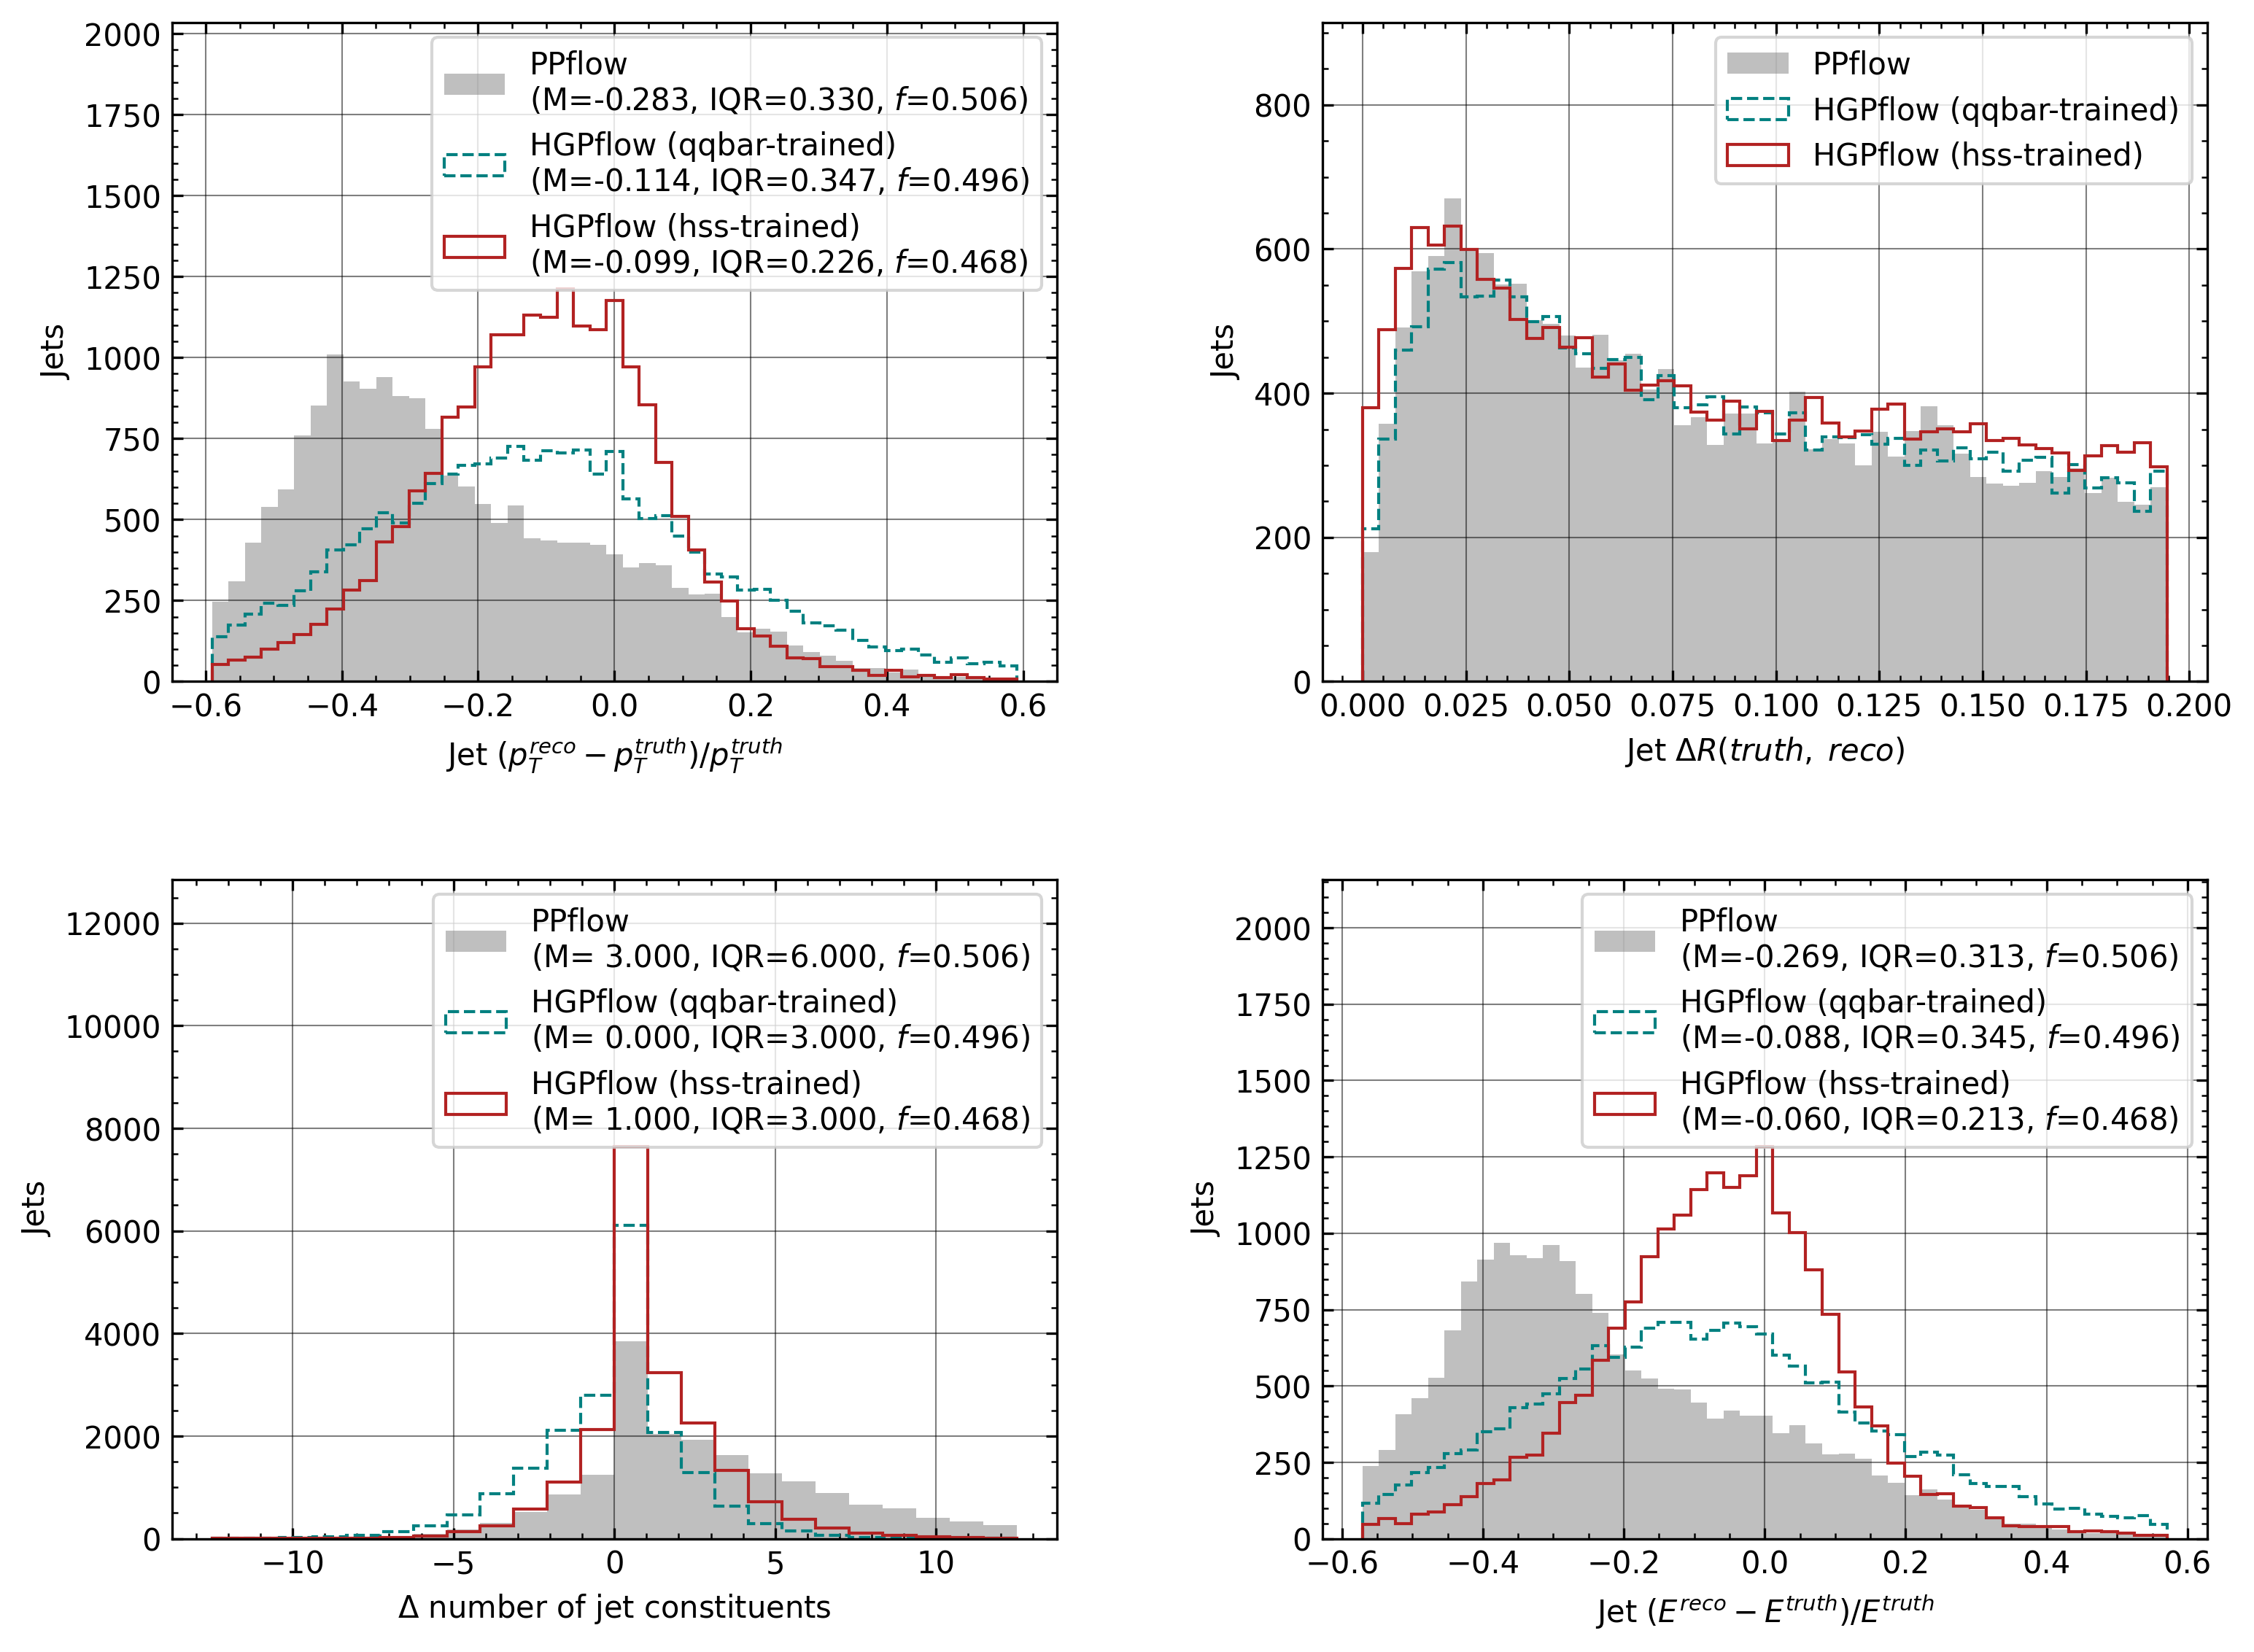

In [10]:
# For LLP jets
FRAC = 0.9
residual_dict_llp = compute_jet_residual_dict({
    'ppflow':        select_matched_by_llp(perf_qqbar.truth_dict['matched_ppflow_jets'],    FRAC, keep='llp'),
    'hgpflow_qqbar': select_matched_by_llp(perf_qqbar.hgpflow_dict['matched_hgpflow_jets'], FRAC, keep='llp'),
    'hgpflow_hss':   select_matched_by_llp(perf_hss.hgpflow_dict['matched_hgpflow_jets'],   FRAC, keep='llp'),
}, dr_cut=0.2)
fig = plot_jet_residuals(residual_dict_llp, pt_relative=True, stylesheet=STYLE)
fig.savefig(f'hss_test_qqbar_vs_hss_jet_residuals_llp{int(FRAC*100)}.png', dpi=150, bbox_inches='tight')


In [11]:
def summarize_matching(residual_dict, title, var='pt_rel'):
    print(f'=== {title} ===')
    print(f"{'curve':16s} {'N_match':>8s} {'N_ref':>7s} {'f +/- err':>16s}   "
          f"{'median':>9s} {'IQR':>8s}")
    for name, res in residual_dict.items():
        r = np.asarray(res[var])
        n_match = len(r)
        f = res['f_matched']
        n_ref = int(round(n_match / f)) if f > 0 else 0
        ferr = np.sqrt(f * (1 - f) / n_ref) if n_ref > 0 else np.nan
        med = np.median(r) if n_match else np.nan
        iqrv = (np.percentile(r, 75) - np.percentile(r, 25)) if n_match else np.nan
        print(f'{name:16s} {n_match:8d} {n_ref:7d}   {f:.3f} +/- {ferr:.3f}   '
              f'{med:9.4f} {iqrv:8.4f}')
    print()

summarize_matching(residual_dict_llp, f'LLP jets (FRAC={FRAC}), pt_rel')
summarize_matching(residual_dict,     'all jets, pt_rel')


=== LLP jets (FRAC=0.9), pt_rel ===
curve             N_match   N_ref        f +/- err      median      IQR
ppflow              19145   37862   0.506 +/- 0.003     -0.2832   0.3297
hgpflow_qqbar       18960   38191   0.496 +/- 0.003     -0.1141   0.3473
hgpflow_hss         20347   43517   0.468 +/- 0.002     -0.0993   0.2258

=== all jets, pt_rel ===
curve             N_match   N_ref        f +/- err      median      IQR
ppflow              42294   69157   0.612 +/- 0.002     -0.1065   0.3612
hgpflow_qqbar       41936   68653   0.611 +/- 0.002     -0.0462   0.2758
hgpflow_hss         43897   75636   0.580 +/- 0.002     -0.0584   0.1966



In [12]:
def jet_multiplicity_and_fakes(reco_ev, truth_ev, dr_cut=0.1, pt_min=10, eta_max=2.5):
    reco_counts, truth_counts = [], []
    n_reco_total, n_fake = 0, 0
    for reco_jets, truth_jets in zip(reco_ev, truth_ev):
        reco_fid  = [r for r in reco_jets  if r.pt > pt_min and abs(r.eta) < eta_max]
        truth_fid = [t for t in truth_jets if t.pt > pt_min and abs(t.eta) < eta_max]
        reco_counts.append(len(reco_fid))
        truth_counts.append(len(truth_fid))
        for r in reco_fid:
            n_reco_total += 1
            if not any(r.delta_R(t) < dr_cut for t in truth_fid):
                n_fake += 1
    fr = n_fake / n_reco_total if n_reco_total else np.nan
    frerr = np.sqrt(fr * (1 - fr) / n_reco_total) if n_reco_total else np.nan
    return dict(mean_reco=np.mean(reco_counts), mean_truth=np.mean(truth_counts),
                n_reco=n_reco_total, n_fake=n_fake, fake_rate=fr, fake_err=frerr)

collections = {
    'ppflow':        (perf_qqbar.truth_dict['ppflow_jets'], perf_qqbar.truth_dict['truth_jets']),
    'hgpflow_qqbar': (perf_qqbar.hgpflow_dict['jets'],      perf_qqbar.truth_dict['truth_jets']),
    'hgpflow_hss':   (perf_hss.hgpflow_dict['jets'],        perf_hss.truth_dict['truth_jets']),
}

DR = 0.1  # set 0.2 to match a looser jet-axis cut
print(f"(dr_cut={DR}, pt>10 GeV, |eta|<2.5)")
print(f"{'curve':16s} {'reco/ev':>8s} {'truth/ev':>9s} {'N_reco':>8s} {'N_fake':>7s} {'fake_rate':>16s}")
for name, (reco_ev, truth_ev) in collections.items():
    s = jet_multiplicity_and_fakes(reco_ev, truth_ev, dr_cut=DR)
    print(f"{name:16s} {s['mean_reco']:8.3f} {s['mean_truth']:9.3f} "
          f"{s['n_reco']:8d} {s['n_fake']:7d}   {s['fake_rate']:.3f} +/- {s['fake_err']:.3f}")


(dr_cut=0.1, pt>10 GeV, |eta|<2.5)
curve             reco/ev  truth/ev   N_reco  N_fake        fake_rate


ppflow              1.894     2.816    56775   26494   0.467 +/- 0.002
hgpflow_qqbar       1.926     2.816    57731   27621   0.478 +/- 0.002
hgpflow_hss         2.165     2.816    64884   33522   0.517 +/- 0.002


In [13]:
import matplotlib.pyplot as plt

def eff_vs_pt(truth_ev, reco_ev, frac=0.9, keep='llp', dr_cut=0.1,
              pt_bins=np.array([10,20,30,50,80,120,200]), eta_max=2.5):
    """Truth-jet-centric matching efficiency vs pT for LLP (or prompt) truth jets:
       fraction of truth jets with >=1 reco jet within dr_cut. Truth jets carry
       .llp_frac from tag_truth_jets_llp(perf)."""
    centers = 0.5*(pt_bins[:-1]+pt_bins[1:])
    num = np.zeros(len(centers)); den = np.zeros(len(centers))
    for truth_jets, reco_jets in zip(truth_ev, reco_ev):
        for t in truth_jets:
            f = getattr(t, 'llp_frac', None)
            if f is None:
                raise RuntimeError("run tag_truth_jets_llp(perf) first")
            passes = (f >= frac) if keep == 'llp' else (f < frac)
            if not passes or abs(t.eta) >= eta_max:
                continue
            b = np.digitize(t.pt, pt_bins) - 1
            if b < 0 or b >= len(centers):
                continue
            den[b] += 1
            if any(t.delta_R(r) < dr_cut for r in reco_jets):
                num[b] += 1
    eff = np.where(den > 0, num/np.where(den>0, den, 1), np.nan)
    err = np.where(den > 0, np.sqrt(eff*(1-eff)/np.where(den>0, den, 1)), np.nan)
    return centers, eff, err, den


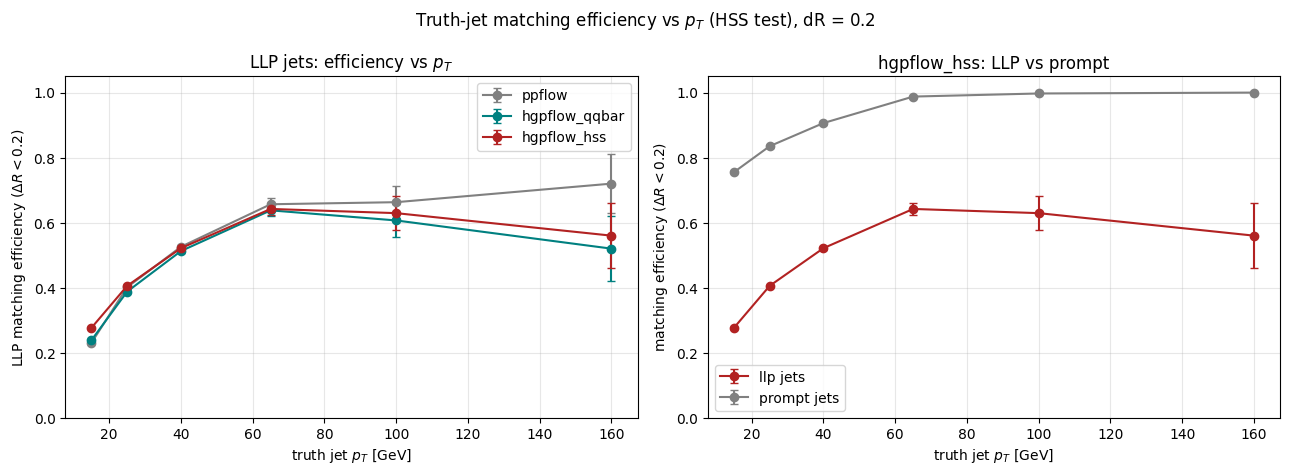

In [14]:
DR = 0.2  # try 0.2 as well

# reco/truth pairs (each model paired with ITS OWN perf's truth jets)
llp_sets = {
    'ppflow':        (perf_qqbar.truth_dict['truth_jets'], perf_qqbar.truth_dict['ppflow_jets'], 'gray'),
    'hgpflow_qqbar': (perf_qqbar.truth_dict['truth_jets'], perf_qqbar.hgpflow_dict['jets'],      'teal'),
    'hgpflow_hss':   (perf_hss.truth_dict['truth_jets'],   perf_hss.hgpflow_dict['jets'],        'firebrick'),
}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))

# Panel 1: LLP-jet efficiency vs pT, three collections
for name, (tj, rj, col) in llp_sets.items():
    c, eff, err, den = eff_vs_pt(tj, rj, frac=0.9, keep='llp', dr_cut=DR)
    a1.errorbar(c, eff, yerr=err, fmt='o-', color=col, capsize=3, label=name)
a1.set(xlabel='truth jet $p_T$ [GeV]', ylabel=f'LLP matching efficiency ($\\Delta R<{DR}$)', ylim=(0, 1.05))
a1.set_title('LLP jets: efficiency vs $p_T$'); a1.grid(alpha=.3); a1.legend()

# Panel 2: hgpflow_hss, LLP vs prompt (is the loss LLP-specific?)
tj, rj = perf_hss.truth_dict['truth_jets'], perf_hss.hgpflow_dict['jets']
for keep, col in [('llp', 'firebrick'), ('prompt', 'gray')]:
    c, eff, err, den = eff_vs_pt(tj, rj, frac=0.9, keep=keep, dr_cut=DR)
    a2.errorbar(c, eff, yerr=err, fmt='o-', color=col, capsize=3, label=f'{keep} jets')
a2.set(xlabel='truth jet $p_T$ [GeV]', ylabel=f'matching efficiency ($\\Delta R<{DR}$)', ylim=(0, 1.05))
a2.set_title('hgpflow_hss: LLP vs prompt'); a2.grid(alpha=.3); a2.legend()

fig.suptitle('Truth-jet matching efficiency vs $p_T$ (HSS test), dR = 0.2')
fig.tight_layout()
fig.savefig(f'hss_test_llp_eff_vs_pt_dr{int(DR*100)}.png', dpi=150, bbox_inches='tight')


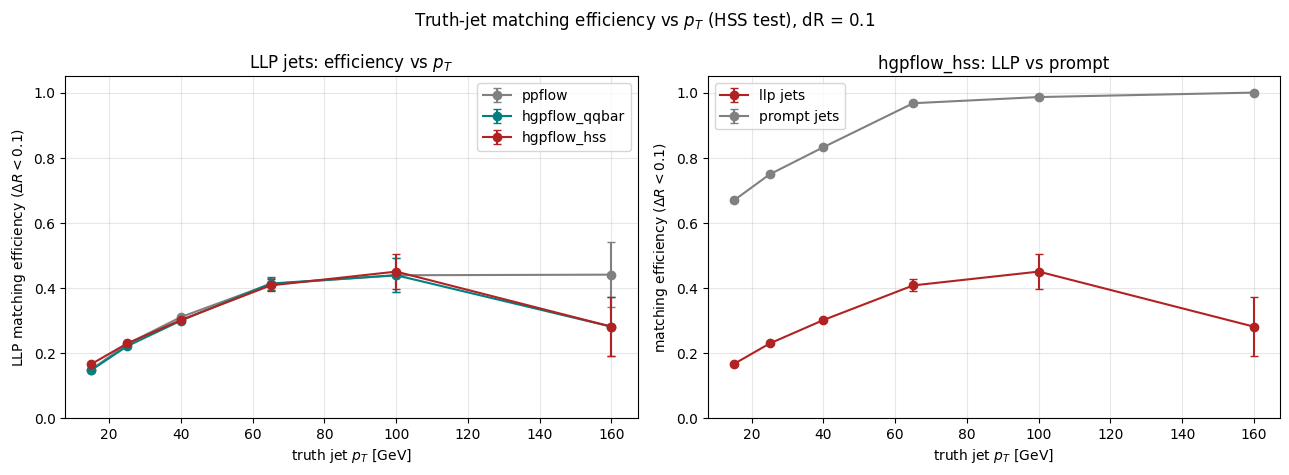

In [15]:
DR = 0.1

# reco/truth pairs (each model paired with ITS OWN perf's truth jets)
llp_sets = {
    'ppflow':        (perf_qqbar.truth_dict['truth_jets'], perf_qqbar.truth_dict['ppflow_jets'], 'gray'),
    'hgpflow_qqbar': (perf_qqbar.truth_dict['truth_jets'], perf_qqbar.hgpflow_dict['jets'],      'teal'),
    'hgpflow_hss':   (perf_hss.truth_dict['truth_jets'],   perf_hss.hgpflow_dict['jets'],        'firebrick'),
}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))

# Panel 1: LLP-jet efficiency vs pT, three collections
for name, (tj, rj, col) in llp_sets.items():
    c, eff, err, den = eff_vs_pt(tj, rj, frac=0.9, keep='llp', dr_cut=DR)
    a1.errorbar(c, eff, yerr=err, fmt='o-', color=col, capsize=3, label=name)
a1.set(xlabel='truth jet $p_T$ [GeV]', ylabel=f'LLP matching efficiency ($\\Delta R<{DR}$)', ylim=(0, 1.05))
a1.set_title('LLP jets: efficiency vs $p_T$'); a1.grid(alpha=.3); a1.legend()

# Panel 2: hgpflow_hss, LLP vs prompt (is the loss LLP-specific?)
tj, rj = perf_hss.truth_dict['truth_jets'], perf_hss.hgpflow_dict['jets']
for keep, col in [('llp', 'firebrick'), ('prompt', 'gray')]:
    c, eff, err, den = eff_vs_pt(tj, rj, frac=0.9, keep=keep, dr_cut=DR)
    a2.errorbar(c, eff, yerr=err, fmt='o-', color=col, capsize=3, label=f'{keep} jets')
a2.set(xlabel='truth jet $p_T$ [GeV]', ylabel=f'matching efficiency ($\\Delta R<{DR}$)', ylim=(0, 1.05))
a2.set_title('hgpflow_hss: LLP vs prompt'); a2.grid(alpha=.3); a2.legend()

fig.suptitle('Truth-jet matching efficiency vs $p_T$ (HSS test), dR = 0.1')
fig.tight_layout()
fig.savefig(f'hss_test_llp_eff_vs_pt_dr{int(DR*100)}.png', dpi=150, bbox_inches='tight')


In [16]:
for name, (tj, rj, col) in llp_sets.items():
    c, eff, err, den = eff_vs_pt(tj, rj, frac=0.9, keep='llp', dr_cut=0.1)
    print(f'--- {name} ---')
    for ci, ei, eri, di in zip(c, eff, err, den):
        print(f'  pT~{ci:6.1f} GeV:  eff={ei:.3f} +/- {eri:.3f}   (N_truth_LLP={int(di)})')


--- ppflow ---
  pT~  15.0 GeV:  eff=0.148 +/- 0.002   (N_truth_LLP=25652)
  pT~  25.0 GeV:  eff=0.227 +/- 0.003   (N_truth_LLP=18153)
  pT~  40.0 GeV:  eff=0.310 +/- 0.005   (N_truth_LLP=10502)
  pT~  65.0 GeV:  eff=0.411 +/- 0.019   (N_truth_LLP=693)
  pT~ 100.0 GeV:  eff=0.438 +/- 0.053   (N_truth_LLP=89)
  pT~ 160.0 GeV:  eff=0.440 +/- 0.099   (N_truth_LLP=25)
--- hgpflow_qqbar ---
  pT~  15.0 GeV:  eff=0.147 +/- 0.002   (N_truth_LLP=25652)
  pT~  25.0 GeV:  eff=0.220 +/- 0.003   (N_truth_LLP=18153)
  pT~  40.0 GeV:  eff=0.299 +/- 0.004   (N_truth_LLP=10502)
  pT~  65.0 GeV:  eff=0.413 +/- 0.019   (N_truth_LLP=693)
  pT~ 100.0 GeV:  eff=0.438 +/- 0.053   (N_truth_LLP=89)
  pT~ 160.0 GeV:  eff=0.280 +/- 0.090   (N_truth_LLP=25)
--- hgpflow_hss ---
  pT~  15.0 GeV:  eff=0.165 +/- 0.002   (N_truth_LLP=25652)
  pT~  25.0 GeV:  eff=0.228 +/- 0.003   (N_truth_LLP=18153)
  pT~  40.0 GeV:  eff=0.301 +/- 0.004   (N_truth_LLP=10502)
  pT~  65.0 GeV:  eff=0.407 +/- 0.019   (N_truth_LLP=693)
 

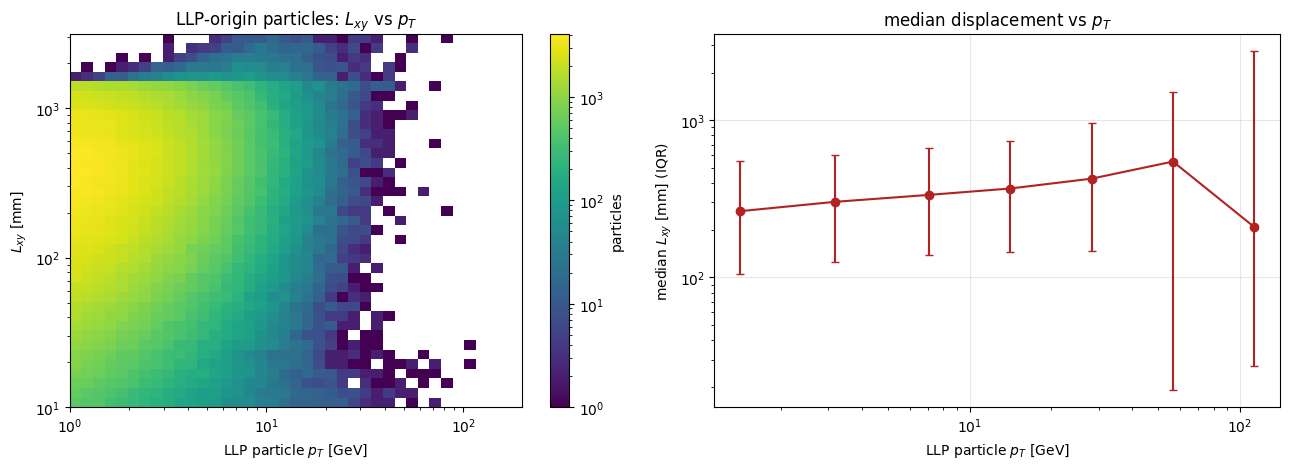

In [17]:
import uproot, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

TRUTH = '/pscratch/sd/a/agolub/hss_events/HSS_events_with_ppflow/cocoa_hss_pflow_30k.root'
a = uproot.open(TRUTH)['Out_Tree'].arrays(
    ['particle_pt','particle_eta','particle_prod_x','particle_prod_y'], library='np')

pt  = np.concatenate(a['particle_pt']) * 1e-3        # MeV -> GeV (loader convention)
eta = np.concatenate(a['particle_eta'])
lxy = np.concatenate([np.hypot(x, y) for x, y in zip(a['particle_prod_x'], a['particle_prod_y'])])  # mm

fid = (pt >= 1) & (np.abs(eta) < 3)      # same fiducial as load_truth_cocoa
llp = fid & (lxy > 10)                    # same LLP tag (llp_lxy_mm=10)
pt_l, lxy_l = pt[llp], lxy[llp]

# median Lxy (with IQR) in pT bins
pt_bins = np.array([1, 2, 5, 10, 20, 40, 80, 160])
centers = np.sqrt(pt_bins[:-1] * pt_bins[1:])
idx = np.digitize(pt_l, pt_bins) - 1
med = np.array([np.median(lxy_l[idx==b]) if (idx==b).any() else np.nan for b in range(len(centers))])
q25 = np.array([np.percentile(lxy_l[idx==b],25) if (idx==b).any() else np.nan for b in range(len(centers))])
q75 = np.array([np.percentile(lxy_l[idx==b],75) if (idx==b).any() else np.nan for b in range(len(centers))])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))
h = a1.hist2d(pt_l, lxy_l, bins=[np.logspace(0, 2.3, 40), np.logspace(1, 3.5, 40)],
              cmap='viridis', norm=LogNorm())
a1.set(xscale='log', yscale='log', xlabel='LLP particle $p_T$ [GeV]', ylabel='$L_{xy}$ [mm]',
       title='LLP-origin particles: $L_{xy}$ vs $p_T$'); fig.colorbar(h[3], ax=a1, label='particles')
a2.errorbar(centers, med, yerr=[med-q25, q75-med], fmt='o-', color='firebrick', capsize=3)
a2.set(xscale='log', yscale='log', xlabel='LLP particle $p_T$ [GeV]',
       ylabel='median $L_{xy}$ [mm] (IQR)', title='median displacement vs $p_T$'); a2.grid(alpha=.3)
fig.tight_layout(); fig.savefig('hss_llp_lxy_vs_pt.png', dpi=150, bbox_inches='tight')


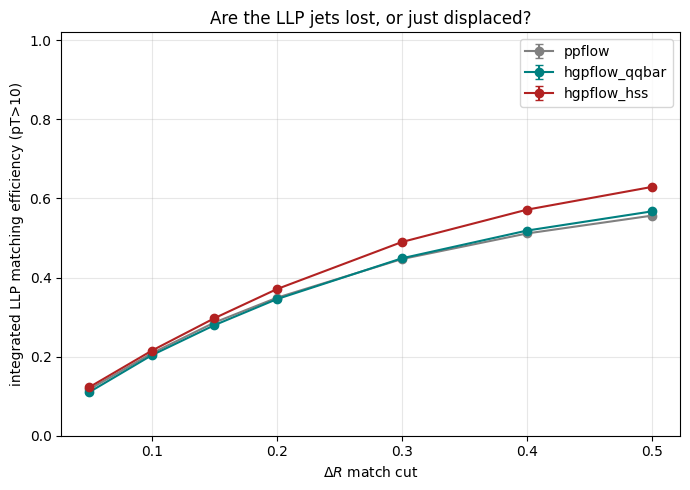

In [18]:
dr_scan = np.array([0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5])
fig, ax = plt.subplots(figsize=(7, 5))
for name, (tj, rj, col) in llp_sets.items():
    effs, errs = [], []
    for dr in dr_scan:
        _, eff, err, den = eff_vs_pt(tj, rj, frac=0.9, keep='llp', dr_cut=dr,
                                     pt_bins=np.array([10, 1e9]))  # one wide bin = integrated (pT>10)
        effs.append(eff[0]); errs.append(err[0])
    ax.errorbar(dr_scan, effs, yerr=errs, fmt='o-', color=col, capsize=3, label=name)
ax.set(xlabel=r'$\Delta R$ match cut', ylabel='integrated LLP matching efficiency (pT>10)',
       title='Are the LLP jets lost, or just displaced?', ylim=(0, 1.02))
ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig('hss_llp_eff_vs_dr.png', dpi=150, bbox_inches='tight')



matched:   median ratio 0.95  (N=11864)
unmatched: median ratio 0.43  (N=43254),  frac <0.2: 0.41


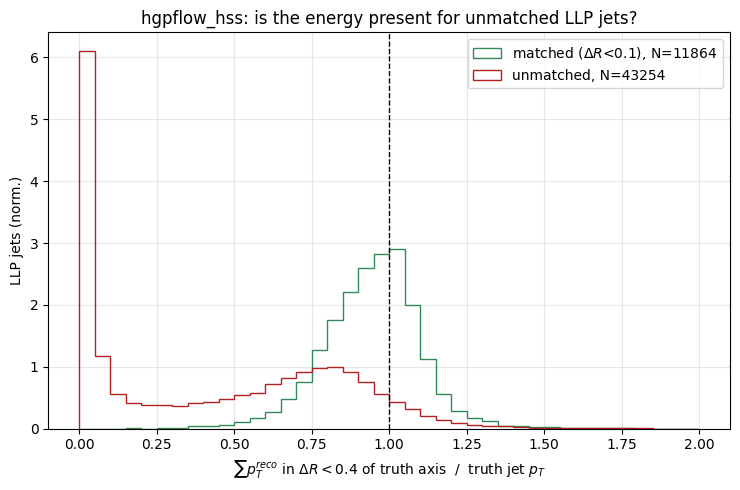

In [19]:
def _dR(eta1, phi1, eta2, phi2):
    dphi = np.abs(phi1 - phi2); dphi = np.where(dphi > np.pi, 2*np.pi - dphi, dphi)
    return np.hypot(eta1 - eta2, dphi)

def cone_energy_ratio(perf, frac=0.9, cone=0.4, dr_match=0.1, pt_min=10, eta_max=2.5):
    tev = perf.truth_dict['truth_jets']; rev = perf.hgpflow_dict['jets']
    ppt, peta, pphi = (perf.hgpflow_dict['hgpflow_pt'],
                       perf.hgpflow_dict['hgpflow_eta'], perf.hgpflow_dict['hgpflow_phi'])
    matched, unmatched = [], []
    for tj, rj, pt_a, eta_a, phi_a in zip(tev, rev, ppt, peta, pphi):
        pt_a, eta_a, phi_a = np.asarray(pt_a), np.asarray(eta_a), np.asarray(phi_a)
        for t in tj:
            if getattr(t, 'llp_frac', 0) < frac or abs(t.eta) >= eta_max or t.pt < pt_min:
                continue
            cone_pt = pt_a[_dR(t.eta, t.phi, eta_a, phi_a) < cone].sum() if len(pt_a) else 0.0
            ratio = cone_pt / t.pt
            (matched if any(t.delta_R(r) < dr_match for r in rj) else unmatched).append(ratio)
    return np.array(matched), np.array(unmatched)

rm, ru = cone_energy_ratio(perf_hss, frac=0.9)
fig, ax = plt.subplots(figsize=(7.5, 5)); bins = np.linspace(0, 2, 41)
ax.hist(rm, bins=bins, histtype='step', color='seagreen', density=True, label=f'matched ($\\Delta R$<0.1), N={len(rm)}')
ax.hist(ru, bins=bins, histtype='step', color='firebrick', density=True, label=f'unmatched, N={len(ru)}')
ax.axvline(1.0, ls='--', c='k', lw=1)
ax.set(xlabel=r'$\sum p_T^{reco}$ in $\Delta R<0.4$ of truth axis  /  truth jet $p_T$',
       ylabel='LLP jets (norm.)', title='hgpflow_hss: is the energy present for unmatched LLP jets?')
ax.legend(); ax.grid(alpha=.3); fig.tight_layout()
fig.savefig('hss_llp_cone_energy_ratio.png', dpi=150, bbox_inches='tight')
print(f'matched:   median ratio {np.median(rm):.2f}  (N={len(rm)})')
print(f'unmatched: median ratio {np.median(ru):.2f}  (N={len(ru)}),  frac <0.2: {(ru<0.2).mean():.2f}')


In [20]:
def cone_class_breakdown(perf, frac=0.9, cone=0.4, dr_match=0.1, pt_min=10, eta_max=2.5):
    tev, rev = perf.truth_dict['truth_jets'], perf.hgpflow_dict['jets']
    ppt, peta, pphi, pcls = (perf.hgpflow_dict['hgpflow_pt'], perf.hgpflow_dict['hgpflow_eta'],
                             perf.hgpflow_dict['hgpflow_phi'], perf.hgpflow_dict['hgpflow_class'])
    rows = []  # matched, Eratio, ch_frac, nh_frac, ph_frac
    for tj, rj, pt_a, eta_a, phi_a, cl_a in zip(tev, rev, ppt, peta, pphi, pcls):
        pt_a, eta_a, phi_a, cl_a = map(np.asarray, (pt_a, eta_a, phi_a, cl_a))
        for t in tj:
            if getattr(t, 'llp_frac', 0) < frac or abs(t.eta) >= eta_max or t.pt < pt_min:
                continue
            inc = _dR(t.eta, t.phi, eta_a, phi_a) < cone if len(pt_a) else np.zeros(0, bool)
            tot = pt_a[inc].sum()
            matched = any(t.delta_R(r) < dr_match for r in rj)
            if tot > 0:
                ch = pt_a[inc & (cl_a <= 2)].sum() / tot
                nh = pt_a[inc & (cl_a == 3)].sum() / tot
                ph = pt_a[inc & (cl_a == 4)].sum() / tot
            else:
                ch = nh = ph = np.nan
            rows.append((matched, tot / t.pt, ch, nh, ph))
    return np.array(rows, dtype=float)

R = cone_class_breakdown(perf_hss, frac=0.9)
for lbl, sel in [('matched', R[:,0] == 1), ('unmatched', R[:,0] == 0)]:
    r = R[sel]; ok = ~np.isnan(r[:,2])
    print(f'{lbl:9s} N={sel.sum():5d}  Eratio med={np.nanmedian(r[:,1]):.2f}  '
          f'<charged>={np.nanmean(r[ok,2]):.2f}  <nh>={np.nanmean(r[ok,3]):.2f}  <photon>={np.nanmean(r[ok,4]):.2f}')


matched   N=11864  Eratio med=0.95  <charged>=0.35  <nh>=0.45  <photon>=0.20
unmatched N=43254  Eratio med=0.43  <charged>=0.07  <nh>=0.74  <photon>=0.19


In [21]:
R08 = cone_class_breakdown(perf_hss, frac=0.9, cone=0.8)
for lbl, sel in [('matched', R08[:,0]==1), ('unmatched', R08[:,0]==0)]:
    r = R08[sel]; ok = ~np.isnan(r[:,2])
    print(f'{lbl:9s} N={sel.sum():5d}  Eratio med={np.nanmedian(r[:,1]):.2f}  '
          f'<charged>={np.nanmean(r[ok,2]):.2f}  <nh>={np.nanmean(r[ok,3]):.2f}  <photon>={np.nanmean(r[ok,4]):.2f}')


matched   N=11864  Eratio med=1.08  <charged>=0.35  <nh>=0.45  <photon>=0.20
unmatched N=43254  Eratio med=0.85  <charged>=0.13  <nh>=0.70  <photon>=0.18


matched   centroid shift: median 0.064  IQR [0.036, 0.102]
unmatched centroid shift: median 0.284  IQR [0.173, 0.445]


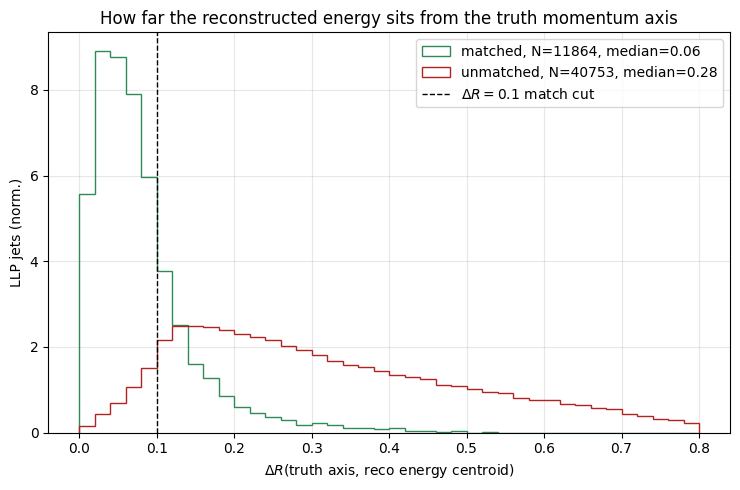

In [22]:
def _dphi(a, b):
    d = a - b
    return (d + np.pi) % (2*np.pi) - np.pi

def cone_centroid_shift(perf, frac=0.9, cone=0.8, dr_match=0.1, pt_min=10, eta_max=2.5):
    tev, rev = perf.truth_dict['truth_jets'], perf.hgpflow_dict['jets']
    ppt, peta, pphi = (perf.hgpflow_dict['hgpflow_pt'], perf.hgpflow_dict['hgpflow_eta'],
                       perf.hgpflow_dict['hgpflow_phi'])
    ms, us = [], []
    for tj, rj, pt_a, eta_a, phi_a in zip(tev, rev, ppt, peta, pphi):
        pt_a, eta_a, phi_a = map(np.asarray, (pt_a, eta_a, phi_a))
        for t in tj:
            if getattr(t, 'llp_frac', 0) < frac or abs(t.eta) >= eta_max or t.pt < pt_min or not len(pt_a):
                continue
            deta, dphi = eta_a - t.eta, _dphi(phi_a, t.phi)
            inc = np.hypot(deta, dphi) < cone
            w = pt_a[inc]
            if w.sum() <= 0:
                continue
            shift = np.hypot(np.average(deta[inc], weights=w), np.average(dphi[inc], weights=w))
            (ms if any(t.delta_R(r) < dr_match for r in rj) else us).append(shift)
    return np.array(ms), np.array(us)

ms, us = cone_centroid_shift(perf_hss, frac=0.9, cone=0.8)
fig, ax = plt.subplots(figsize=(7.5, 5)); bins = np.linspace(0, 0.8, 41)
ax.hist(ms, bins=bins, histtype='step', color='seagreen', density=True,
        label=f'matched, N={len(ms)}, median={np.median(ms):.2f}')
ax.hist(us, bins=bins, histtype='step', color='firebrick', density=True,
        label=f'unmatched, N={len(us)}, median={np.median(us):.2f}')
ax.axvline(0.1, ls='--', c='k', lw=1, label=r'$\Delta R=0.1$ match cut')
ax.set(xlabel=r'$\Delta R$(truth axis, reco energy centroid)', ylabel='LLP jets (norm.)',
       title='How far the reconstructed energy sits from the truth momentum axis')
ax.legend(); ax.grid(alpha=.3); fig.tight_layout()
fig.savefig('hss_llp_energy_centroid_shift.png', dpi=150, bbox_inches='tight')
print(f'matched   centroid shift: median {np.median(ms):.3f}  IQR [{np.percentile(ms,25):.3f}, {np.percentile(ms,75):.3f}]')
print(f'unmatched centroid shift: median {np.median(us):.3f}  IQR [{np.percentile(us,25):.3f}, {np.percentile(us,75):.3f}]')


In [23]:
import uproot
TRUTH = '/pscratch/sd/a/agolub/hss_events/HSS_events_with_ppflow/cocoa_hss_pflow_30k.root'
_raw = uproot.open(TRUTH)['Out_Tree'].arrays(
    ['particle_pt','particle_eta','particle_prod_x','particle_prod_y'], library='np')
LLP_MM = perf_hss.llp_lxy_mm  # 10

def per_event_lxy(perf, ev):
    """Lxy per truth particle, index-aligned with perf.truth_dict['particle_*'][ev]."""
    raw = int(perf.truth_dict['event_number'][ev])          # offset=0, positional -> raw entry idx
    pt  = _raw['particle_pt'][raw] * 1e-3                     # MeV -> GeV (loader convention)
    eta = _raw['particle_eta'][raw]
    mask = (pt >= 1) & (np.abs(eta) < 3)                     # exact loader fiducial
    return np.hypot(_raw['particle_prod_x'][raw], _raw['particle_prod_y'][raw])[mask]

def validate_alignment(perf, n_check=300):
    bad = 0
    for ev in range(min(n_check, len(perf.truth_dict['event_number']))):
        lxy, stored = per_event_lxy(perf, ev), perf.truth_dict['particle_llp_origin'][ev]
        if len(lxy) != len(stored) or not np.array_equal(lxy > LLP_MM, stored):
            bad += 1
    print(f'alignment mismatches: {bad}/{min(n_check, len(perf.truth_dict["event_number"]))}')
    return bad == 0

assert validate_alignment(perf_hss), "Lxy re-alignment failed -- do NOT trust the plot"


alignment mismatches: 0/300


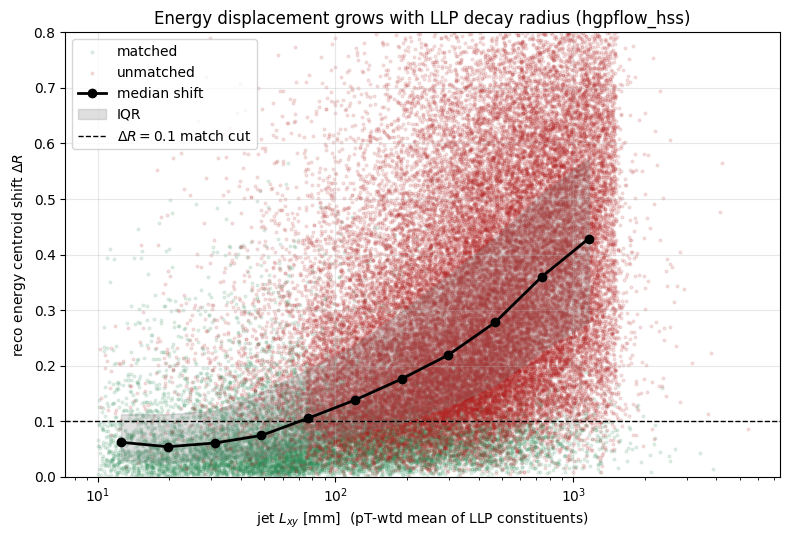

In [24]:
def shift_vs_lxy(perf, frac=0.9, cone=0.8, dr_match=0.1, pt_min=10, eta_max=2.5):
    tev, rev = perf.truth_dict['truth_jets'], perf.hgpflow_dict['jets']
    ppt, peta, pphi = (perf.hgpflow_dict['hgpflow_pt'], perf.hgpflow_dict['hgpflow_eta'],
                       perf.hgpflow_dict['hgpflow_phi'])
    llp_all, pt_all = perf.truth_dict['particle_llp_origin'], perf.truth_dict['particle_pt']
    rows = []  # matched, lxy_jet, shift
    for ev, (tj, rj, pt_a, eta_a, phi_a) in enumerate(zip(tev, rev, ppt, peta, pphi)):
        pt_a, eta_a, phi_a = map(np.asarray, (pt_a, eta_a, phi_a))
        lxy_ev = per_event_lxy(perf, ev)
        for t in tj:
            if getattr(t, 'llp_frac', 0) < frac or abs(t.eta) >= eta_max or t.pt < pt_min or not len(pt_a):
                continue
            idxs = t.constituent_idxs
            sel = llp_all[ev][idxs]                          # LLP-origin constituents
            if sel.sum() == 0:
                continue
            lxy_jet = np.average(lxy_ev[idxs][sel], weights=pt_all[ev][idxs][sel])
            deta, dphi = eta_a - t.eta, _dphi(phi_a, t.phi)
            inc = np.hypot(deta, dphi) < cone
            if pt_a[inc].sum() <= 0:
                continue
            shift = np.hypot(np.average(deta[inc], weights=pt_a[inc]),
                             np.average(dphi[inc], weights=pt_a[inc]))
            rows.append((any(t.delta_R(r) < dr_match for r in rj), lxy_jet, shift))
    return np.array(rows, dtype=float)

D = shift_vs_lxy(perf_hss, frac=0.9)
lxy, shift, matched = D[:,1], D[:,2], D[:,0] == 1

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(lxy[matched],  shift[matched],  s=4, alpha=0.12, color='seagreen',  label='matched')
ax.scatter(lxy[~matched], shift[~matched], s=4, alpha=0.12, color='firebrick', label='unmatched')
bins = np.logspace(np.log10(10), np.log10(np.percentile(lxy, 99)), 12)
cen, idx = np.sqrt(bins[:-1]*bins[1:]), np.digitize(lxy, bins) - 1
med = np.array([np.median(shift[idx==b]) if (idx==b).sum() >= 10 else np.nan for b in range(len(cen))])
q25 = np.array([np.percentile(shift[idx==b],25) if (idx==b).sum() >= 10 else np.nan for b in range(len(cen))])
q75 = np.array([np.percentile(shift[idx==b],75) if (idx==b).sum() >= 10 else np.nan for b in range(len(cen))])
ax.plot(cen, med, 'o-', color='black', lw=2, label='median shift')
ax.fill_between(cen, q25, q75, color='gray', alpha=0.25, label='IQR')
ax.axhline(0.1, ls='--', c='k', lw=1, label=r'$\Delta R=0.1$ match cut')
ax.set(xscale='log', xlabel=r'jet $L_{xy}$ [mm]  (pT-wtd mean of LLP constituents)',
       ylabel=r'reco energy centroid shift $\Delta R$', ylim=(0, 0.8),
       title='Energy displacement grows with LLP decay radius (hgpflow_hss)')
ax.grid(alpha=.3); ax.legend(); fig.tight_layout()
fig.savefig('hss_llp_shift_vs_lxy.png', dpi=150, bbox_inches='tight')
